# Instructor Playground

Investigating Instructor module and Stanford AI API to pass PNG images into LLM models

# Setup

## Imports

In [9]:
import instructor
import base64
from instructor.processing.multimodal import PDF
from PIL import Image
from openai import OpenAI
from pydantic import BaseModel
from dotenv import load_dotenv
from pathlib import Path

import os
import requests
import sys
import matplotlib.pyplot as plt

script_dir = os.path.abspath('/zfs/projects/students/ltdarc-usf-intern-2025/LLM_benchmarks/scripts')
sys.path.append(script_dir)
import helper

In [10]:
load_dotenv("/zfs/projects/students/ltdarc-usf-intern-2025/.env")

True

Set up Instructor client with Stanford API

In [5]:
client = instructor.from_openai(
    OpenAI(
        base_url="https://aiapi-prod.stanford.edu/v1", # <--- THE KEY CHANGE
        api_key=os.environ['STANFORD_API_KEY'],             # Use your school key here
    ),
    mode=instructor.Mode.JSON,
)

## Stanford API

In [11]:
STANFORD_API_KEY = os.environ['STANFORD_API_KEY']

Getting a list of available models via Stanford AI API

In [15]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

In [8]:
ENDPOINT = "https://aiapi-prod.stanford.edu/v1/models"
HEADERS = {
    "Authorization": f"Bearer {STANFORD_API_KEY}",
    "Content-Type": "application/json"
}

resp = requests.get(ENDPOINT, headers=HEADERS)

results = resp.json()

for result in results['data']:
    print(result['id'])

claude-3-haiku
claude-3-5-sonnet
claude-3-7-sonnet
deepseek-r1
gemini-2.0-flash-001
gemini-2.0-flash-lite-001
llama-3.2
gpt-4
gpt-4.omini
gpt-4o
o1
o3-mini
claude-4-sonnet
gemini-2.5-pro
imagen-3.0-generate-002
gpt-5
gpt-5-mini
text-embedding-ada-002
gpt-4.1
DeepSeek-V3-0324


# Inputs

Converting a test PNG into B64

In [12]:
png_path = "/zfs/projects/students/ltdarc-usf-intern-2025/Jeff_tutorial/png_files/Arizona_Republic_Sun__Dec_17__2000_ (15).png"

(np.float64(-0.5), np.float64(2479.5), np.float64(3508.5), np.float64(-0.5))

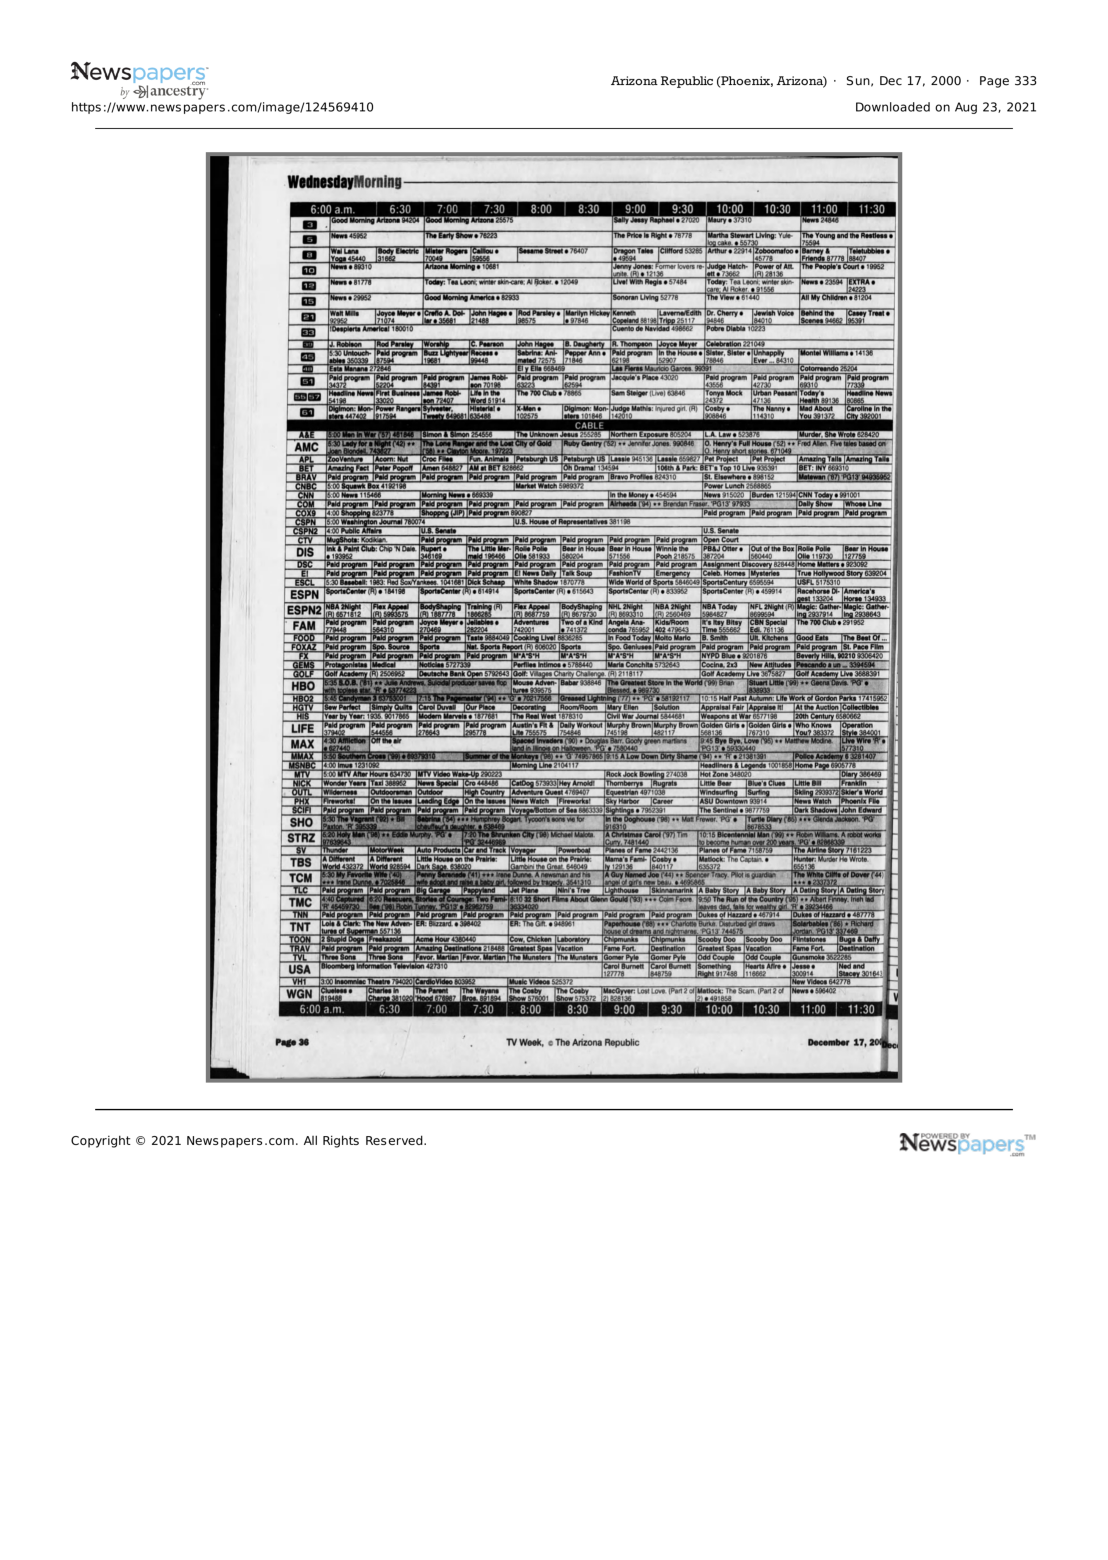

In [13]:
img = Image.open(png_path)
plt.figure(figsize=(20, 20))
plt.imshow(img)
plt.axis("off")

In [16]:
img = encode_image(png_path)

Defining pydantic model for structured output

In [10]:
class meta_data(BaseModel):
    publication_date: str
    day_of_week: str
    tv_guide_date: str

Test Prompt

In [17]:
TEST_USER = f"""Analyze this newspaper TV guide and extract the date the newspaper was published, the day of the week the TV guide is for, and then calculate the date of the tv guide."""

Selecting only vision supported models from Stanford AI

In [12]:
Models = [
    'gpt-4',
    'gpt-4.omini',
    'gpt-4o',
    'claude-3-haiku' ,
    'claude-3-5-sonnet',
    'claude-3-7-sonnet',
    'gemini-2.0-flash-lite-001',
    'gemini-2.0-flash-001',
    'o1',
    'o3-mini',
    'llama-3.2',
    'gpt-4.1',
    'claude-4-sonnet',
    'gpt-5',
    'gpt-5-mini',
    'gemini-2.5-pro'
]

#test playground to see if you can pass image direclty with relative accuracy
#test instructor to call API directly and see accuracy.

# Instructor & Stanford AI

Tried a few different ways to pass the image into Stanford AI LLMs via Instructor. The first method seems to be the least error prone but I think the models aren't actually registering the image.

In [14]:
for model in Models:
    try:
        resp = client.chat.completions.create(
            model=model, 
            response_model=meta_data,
                messages=[
                        {
                            "role": "user",
                            "content": (TEST_USER),
                            "images": [img],
                        }
                    ],
        )
        print(model)
        print(resp)
    except:
        print(f"{model} produced error") 

gpt-4
publication_date='2024-06-10' day_of_week='Tuesday' tv_guide_date='2024-06-11'
gpt-4.omini
publication_date='2023-10-01' day_of_week='Sunday' tv_guide_date='2023-10-01'
gpt-4o
publication_date='' day_of_week='' tv_guide_date=''
claude-3-haiku produced error
claude-3-5-sonnet
publication_date='<UNKNOWN>' day_of_week='<UNKNOWN>' tv_guide_date='<UNKNOWN>'
claude-3-7-sonnet
publication_date='<UNKNOWN>' day_of_week='<UNKNOWN>' tv_guide_date='<UNKNOWN>'
gemini-2.0-flash-lite-001
publication_date='2023-12-24' day_of_week='Sunday' tv_guide_date='2023-12-24'
gemini-2.0-flash-001
publication_date='Unknown' day_of_week='Unknown' tv_guide_date='Unknown'
o1
publication_date='2023-10-12' day_of_week='Thursday' tv_guide_date='2023-10-19'
o3-mini
publication_date='2023-10-11' day_of_week='Friday' tv_guide_date='2023-10-13'
llama-3.2 produced error
gpt-4.1
publication_date='' day_of_week='' tv_guide_date=''
claude-4-sonnet
publication_date='<UNKNOWN>' day_of_week='<UNKNOWN>' tv_guide_date='<UNKNO

In [14]:
for model in Models:
    try:
        resp = client.chat.completions.create(
            model=model, 
            response_model=meta_data,
                messages=[
                        {
                            "role": "user",
                            "content": [
                                (TEST_USER),
                                img
                            ]
                        }
                    ],
        )
        print(model)
        print(resp)
    except:
        print(f"{model} produced error")  

gpt-4 produced error
gpt-4.omini produced error
gpt-4o produced error
claude-3-haiku produced error
claude-3-5-sonnet produced error
claude-3-7-sonnet produced error
gemini-2.0-flash-lite-001 produced error
gemini-2.0-flash-001 produced error
o1 produced error
o3-mini produced error
llama-3.2 produced error
gpt-4.1 produced error
claude-4-sonnet produced error
gpt-5 produced error
gpt-5-mini produced error
gemini-2.5-pro produced error


In [13]:
for model in Models:
    try:
        resp = client.chat.completions.create(
            model=model, 
            response_model=meta_data,
                messages=[
                        {
                            "role": "user",
                            "content": [
                                 {
                                     "type": "text",
                                     "text": (TEST_USER)
                                 },
                                 {
                                     "type": "input_file",
                                     "file": img
                                 }
                            ]
                        }
                    ],
        )
        print(model)
        print(resp)
    except:
        print(f"{model} produced error")  

gpt-4 produced error
gpt-4.omini produced error
gpt-4o produced error
claude-3-haiku produced error
claude-3-5-sonnet produced error
claude-3-7-sonnet produced error
gemini-2.0-flash-lite-001 produced error
gemini-2.0-flash-001 produced error
o1 produced error
o3-mini produced error
llama-3.2 produced error
gpt-4.1 produced error
claude-4-sonnet produced error
gpt-5 produced error
gpt-5-mini produced error
gemini-2.5-pro produced error


# Instructor

Pass converted PNG into GPT-5 via Instructor, result is accurate.

## Setup

In [15]:
OPENAI_API_KEY = os.environ['OPENAI_API_KEY']

In [16]:
client = instructor.from_provider(
    "openai/gpt-5",
    api_key=OPENAI_API_KEY,
)

In [24]:
from instructor.processing.multimodal import Image

## Calling LLM

In [26]:
resp = client.create( 
        response_model=meta_data,
            messages=[
                    {
                        "role": "user",
                        "content": [
                            (TEST_USER),
                            Image.from_path(png_path),
                        ]
                    }
                ],
    )

In [27]:
print(resp)

publication_date='2000-12-17' day_of_week='Wednesday' tv_guide_date='2000-12-20'


# Stanford AI

Pass image to GPT-5 via Stanford API, ran into bad request error.

## Setup

In [18]:
STANFORD_API_KEY = os.getenv("STANFORD_API_KEY")
ENDPOINT = "https://aiapi-prod.stanford.edu/v1/chat/completions"
HEADERS = {
    "Authorization": f"Bearer {STANFORD_API_KEY}",
    "Content-Type": "application/json"
}

In [19]:
messages = [
    {"role": "user", 
         "content": [
             {
                 "type": "text",
                 "text": (TEST_USER)
             },
             {
                 "type": "file",
                 "file": {
                     "file_data": f"data:application/pdf;{img}"}}
],},]

payload = {
    "model": "gpt-5",
    "messages": messages,
}

resp = requests.post(ENDPOINT, headers=HEADERS, json=payload)

print(resp.json())

{'error': {'message': "litellm.BadRequestError: AzureException BadRequestError - Missing required parameter: 'messages[0].content[1].file.file_id'.. Received Model Group=gpt-5\nAvailable Model Group Fallbacks=None", 'type': 'invalid_request_error', 'param': 'messages[0].content[1].file.file_id', 'code': '400'}}
